## Run initially to download data otherwise ignore

In [1]:
pip install kagglehub

  Using cached kagglehub-0.3.13-py3-none-any.whl.metadata (38 kB)
Using cached kagglehub-0.3.13-py3-none-any.whl (68 kB)

   ------------- -------------------------- 1/3 [pyyaml]
   -------------------------- ------------- 2/3 [kagglehub]
   ---------------------------------------- 3/3 [kagglehub]

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tunguz/superconductivty-data-data-set")

print("Path to dataset files:", path)

c:\Users\pchtc\anaconda3\envs\NN\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\pchtc\.cache\kagglehub\datasets\tunguz\superconductivty-data-data-set\versions\1


## Main code

In [2]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import metrics


# maximize display of dataframe columns
pd.set_option('display.max_columns', None)

In [3]:


file = r"C:\Users\pchtc\.cache\kagglehub\datasets\tunguz\superconductivty-data-data-set\versions\1\train.csv"

with open(file, 'r') as f:
    reader = csv.reader(f)
    labels = next(reader)
    data = [row for row in reader]

df = pd.DataFrame(data, columns=labels)

In [4]:
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,wtd_std_atomic_mass,mean_fie,wtd_mean_fie,gmean_fie,wtd_gmean_fie,entropy_fie,wtd_entropy_fie,range_fie,wtd_range_fie,std_fie,wtd_std_fie,mean_atomic_radius,wtd_mean_atomic_radius,gmean_atomic_radius,wtd_gmean_atomic_radius,entropy_atomic_radius,wtd_entropy_atomic_radius,range_atomic_radius,wtd_range_atomic_radius,std_atomic_radius,wtd_std_atomic_radius,mean_Density,wtd_mean_Density,gmean_Density,wtd_gmean_Density,entropy_Density,wtd_entropy_Density,range_Density,wtd_range_Density,std_Density,wtd_std_Density,mean_ElectronAffinity,wtd_mean_ElectronAffinity,gmean_ElectronAffinity,wtd_gmean_ElectronAffinity,entropy_ElectronAffinity,wtd_entropy_ElectronAffinity,range_ElectronAffinity,wtd_range_ElectronAffinity,std_ElectronAffinity,wtd_std_ElectronAffinity,mean_FusionHeat,wtd_mean_FusionHeat,gmean_FusionHeat,wtd_gmean_FusionHeat,entropy_FusionHeat,wtd_entropy_FusionHeat,range_FusionHeat,wtd_range_FusionHeat,std_FusionHeat,wtd_std_FusionHeat,mean_ThermalConductivity,wtd_mean_ThermalConductivity,gmean_ThermalConductivity,wtd_gmean_ThermalConductivity,entropy_ThermalConductivity,wtd_entropy_ThermalConductivity,range_ThermalConductivity,wtd_range_ThermalConductivity,std_ThermalConductivity,wtd_std_ThermalConductivity,mean_Valence,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.9444675,57.8626922857143,66.3615924315719,36.1166119053847,1.1817952393305,1.06239554519617,122.90607,31.7949208571429,51.9688277861034,53.6225345301219,775.425,1010.26857142857,718.15289995213,938.016780052204,1.30596703599158,0.791487788469155,810.6,735.985714285714,323.811807806633,355.562966713294,160.25,105.514285714286,136.126003095455,84.528422716633,1.25924397214289,1.20703998701461,205,42.9142857142857,75.2375404967494,69.2355694829807,4654.35725,2961.50228571429,724.953210852388,53.5438109235142,1.03312880053102,0.814598190091683,8958.571,1579.58342857143,3306.1628967555,3572.59662370838,81.8375,111.727142857143,60.1231785550982,99.4146820543113,1.15968659338134,0.787381690763223,127.05,80.9871428571429,51.4337118896741,42.55839575195,6.9055,3.84685714285714,3.47947484936327,1.04098598567486,1.08857534188499,0.994998193254128,12.878,1.74457142857143,4.59906411675245,4.66691955388659,107.756645,61.0151885714286,7.06248773046785,0.62197948704754,0.308147989812345,0.262848266362233,399.97342,57.1276685714286,168.854243757651,138.51716251123,2.25,2.25714285714286,2.21336383940064,2.21978342968743,1.36892236074022,1.0662210317362,1,1.08571428571429,0.433012701892219,0.43705881545081,29
1,5,92.729214,58.5184161428571,73.1327872225065,36.3966020291995,1.44930919335685,1.05775512271911,122.90607,36.161939,47.0946331703134,53.9798696513451,766.44,1010.61285714286,720.605510513725,938.745412527433,1.54414454326973,0.807078214938731,810.6,743.164285714286,290.183029138508,354.963511171592,161.2,104.971428571429,141.465214777999,84.3701669575628,1.50832754035259,1.2041147982326,205,50.5714285714286,67.321319060161,68.0088169554027,5821.4858,3021.01657142857,1237.09508033858,54.0957182556368,1.31444218462105,0.914802177066343,10488.571,1667.38342857143,3767.40317577062,3632.64918471043,90.89,112.316428571429,69.8333146094209,101.166397739874,1.42799655342352,0.83866646563365,127.05,81.2078571428572,49.4381674417651,41.6676207979191,7.7844,3.79685714285714,4.40379049753476,1.03525111582814,1.37497728009085,1.07309384625263,12.878,1.59571428571429,4.47336265464807,4.60300005985449,172.205316,61.3723314285714,16.0642278788044,0.619734632330547,0.847404163195705,0.567706107876637,429.97342,51.4133828571429,198.554600255545,139.630922368904,2,2.25714285714286,1.8881750225898,2.21067940870655,1.55711309805765,1.04722136819323,2,1.12857142857143,0.632455532033676

Missing values per column:
number_of_elements       0
mean_atomic_mass         0
wtd_mean_atomic_mass     0
gmean_atomic_mass        0
wtd_gmean_atomic_mass    0
                        ..
range_Valence            0
wtd_range_Valence        0
std_Valence              0
wtd_std_Valence          0
critical_temp            0
Length: 82, dtype: int64


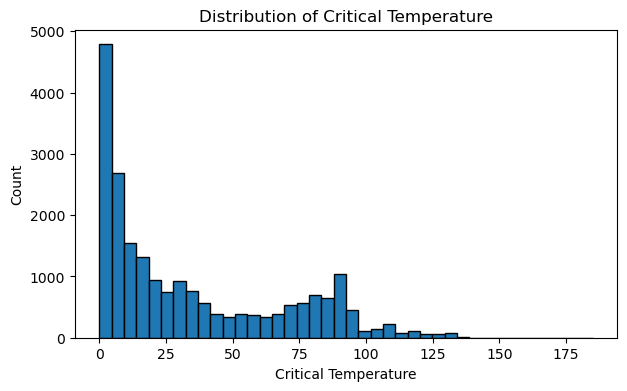

In [5]:
###########################################
# LOAD LIBRARIES AND DATA
###########################################
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LassoCV, Lasso, LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

pd.set_option('display.max_columns', None)

file = r"C:\Users\pchtc\.cache\kagglehub\datasets\tunguz\superconductivty-data-data-set\versions\1\train.csv"

# Load dataset
df = pd.read_csv(file)



########################################################
# 1. EDA (Exploratory Data Analysis)
########################################################

# Missing values
print("Missing values per column:")
print(df.isna().sum())

# Histogram of the target variable
plt.figure(figsize=(7,4))
plt.hist(df['critical_temp'], bins=40, edgecolor='black')
plt.title("Distribution of Critical Temperature")
plt.xlabel("Critical Temperature")
plt.ylabel("Count")
plt.show()




===== BASELINE LINEAR REGRESSION (CV Results) =====
Mean R² (CV): 0.734
Mean RMSE (CV): 17.699


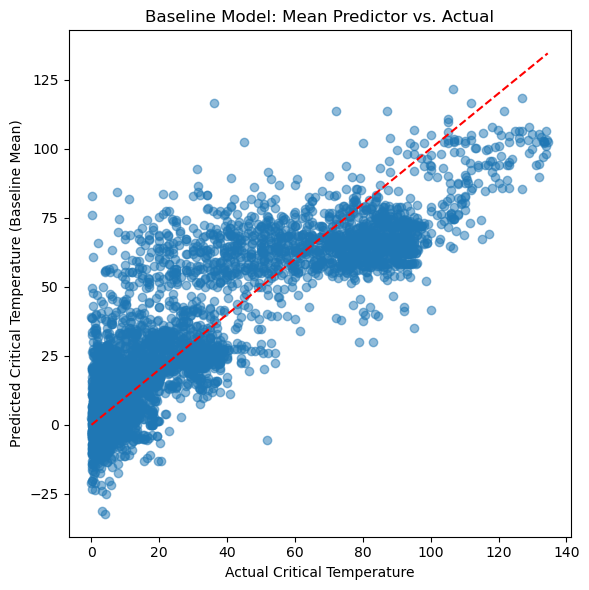

In [6]:
########################################################
# 2. TRAIN / TEST SPLIT + STANDARDIZATION
########################################################

X = df.drop('critical_temp', axis=1)
y = df['critical_temp']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



########################################################
# 3. BASELINE MODEL — OLS REGRESSION
########################################################

baseline = LinearRegression()

cv = KFold(n_splits=5, shuffle=True, random_state=42)

baseline_cv = cross_validate(
    baseline, X_train_scaled, y_train,
    cv=cv, scoring=("r2", "neg_root_mean_squared_error")
)
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)

print("\n===== BASELINE LINEAR REGRESSION (CV Results) =====")
print(f"Mean R² (CV): {baseline_cv['test_r2'].mean():.3f}")
print(f"Mean RMSE (CV): {-baseline_cv['test_neg_root_mean_squared_error'].mean():.3f}")
plt.figure(figsize=(6, 6))
plt.scatter(y_test, baseline_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Critical Temperature")
plt.ylabel("Predicted Critical Temperature (Baseline Mean)")
plt.title("Baseline Model: Mean Predictor vs. Actual")
plt.tight_layout()
plt.show()

c:\Users\pchtc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.406e+06, tolerance: 2.005e+03
  model = cd_fast.enet_coordinate_descent(



Best alpha from GridSearchCV: 0.000100


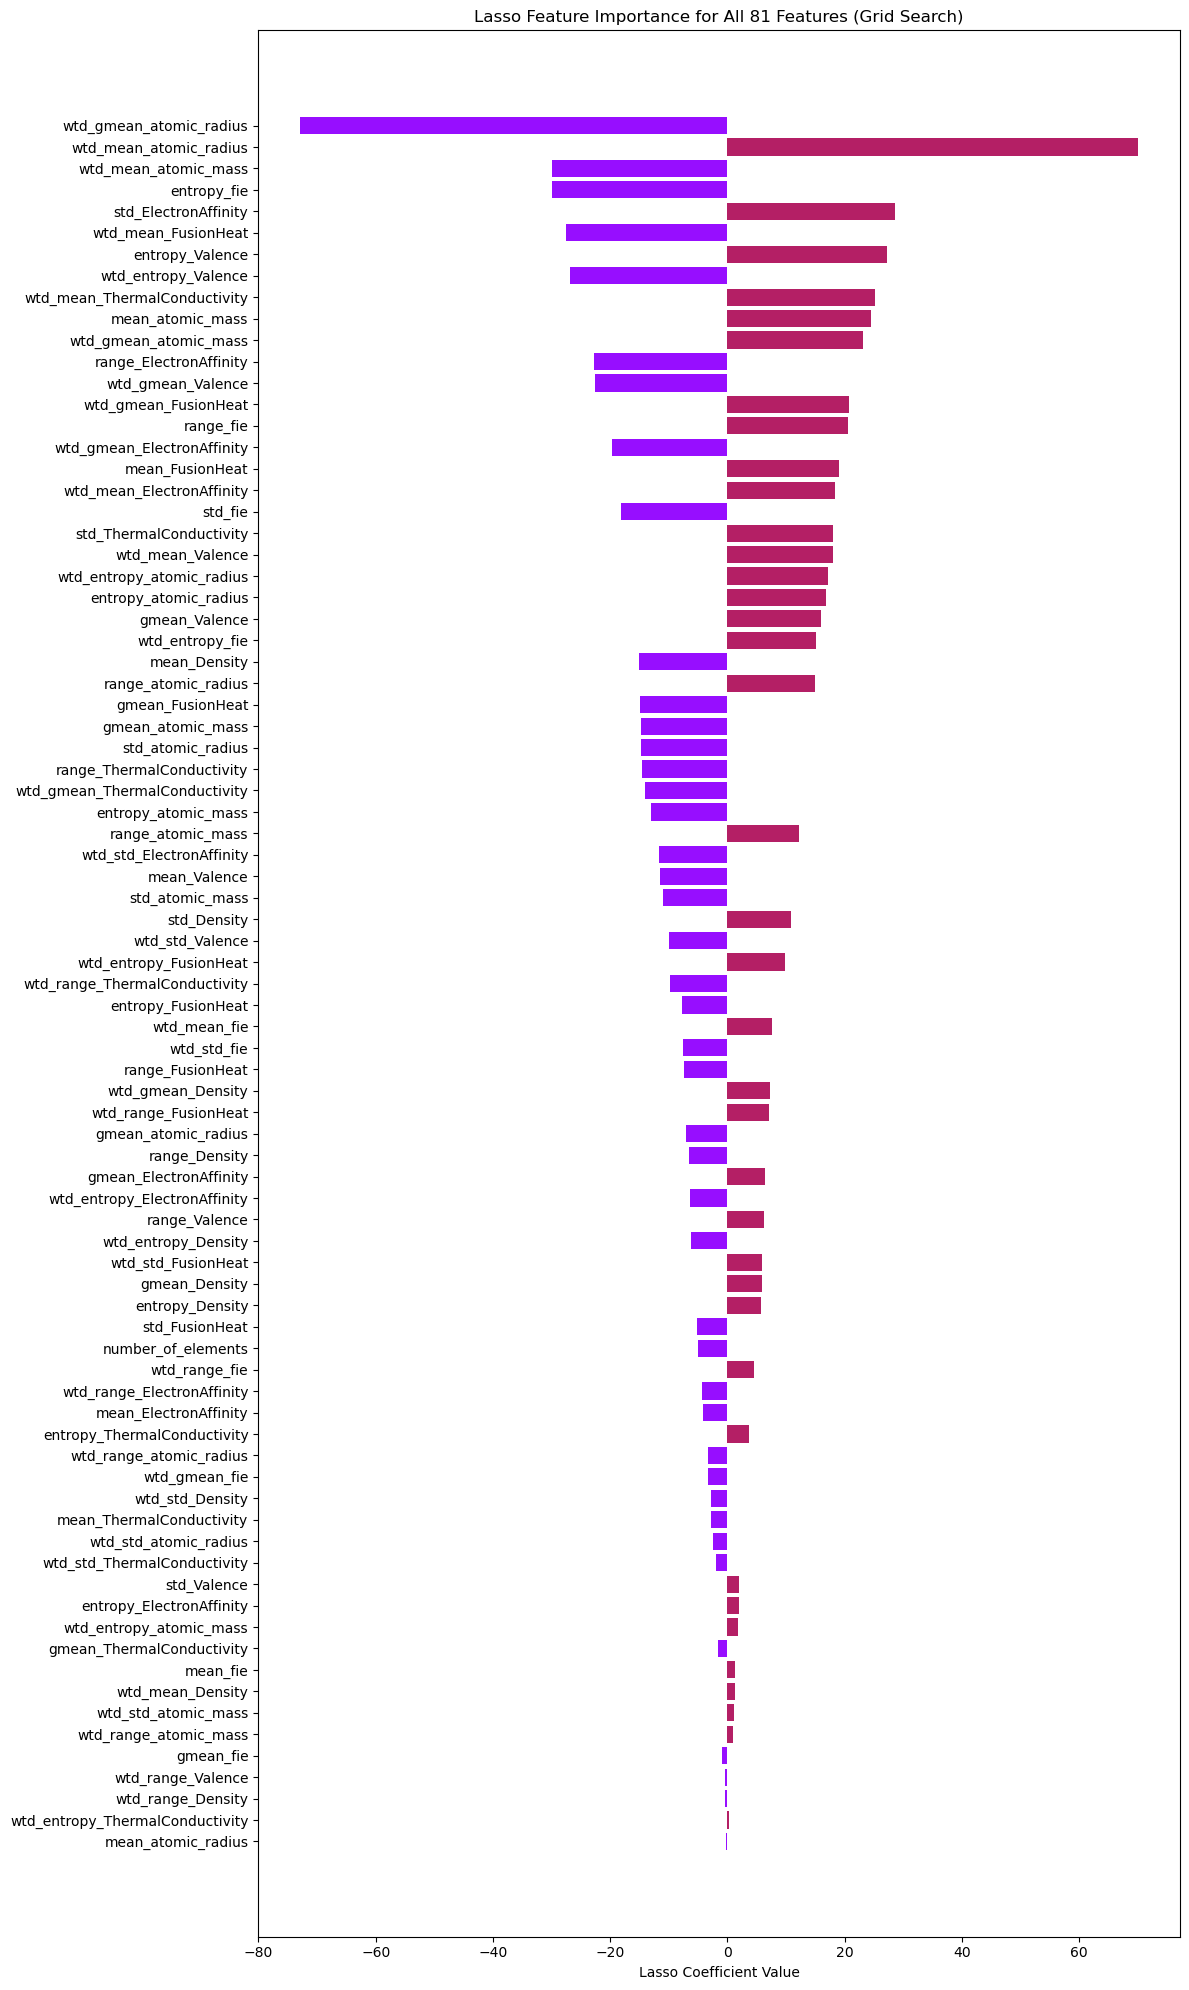


Top 15 Features by Absolute Coefficient:
                         Feature  Coefficient   abs_coef
17                     range_fie    20.598984  20.598984
54          wtd_gmean_FusionHeat    20.669213  20.669213
74             wtd_gmean_Valence   -22.605731  22.605731
47        range_ElectronAffinity   -22.688829  22.688829
4          wtd_gmean_atomic_mass    23.137242  23.137242
1               mean_atomic_mass    24.475114  24.475114
62  wtd_mean_ThermalConductivity    25.204591  25.204591
76           wtd_entropy_Valence   -26.851709  26.851709
75               entropy_Valence    27.184005  27.184005
52           wtd_mean_FusionHeat   -27.555409  27.555409
49          std_ElectronAffinity    28.597804  28.597804
15                   entropy_fie   -29.869115  29.869115
2           wtd_mean_atomic_mass   -29.964377  29.964377
22        wtd_mean_atomic_radius    70.049917  70.049917
24       wtd_gmean_atomic_radius   -72.896465  72.896465

===== LASSO TEST SET PERFORMANCE =====
Test R

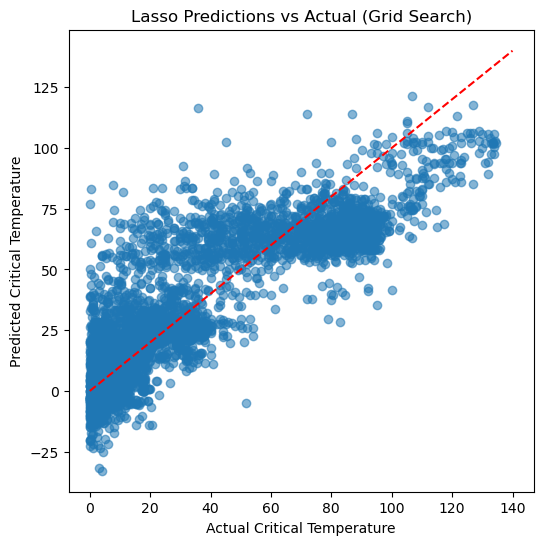

In [7]:
########################################################
# 4. LASSO REGRESSION WITH CROSS-VALIDATED GRID SEARCH
########################################################

# Define logarithmic grid of alpha values
alpha_grid = np.logspace(-4, 2, 50)   # From 0.0001 to 100

param_grid = {
    'alpha': alpha_grid
}

# GridSearchCV for Lasso
grid_search = GridSearchCV(
    estimator=Lasso(max_iter=10000, random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_alpha = grid_search.best_params_['alpha']
print(f"\nBest alpha from GridSearchCV: {best_alpha:.6f}")

# Best Lasso model
lasso = grid_search.best_estimator_


########################################################
# 4B. COEFFICIENT ANALYSIS
########################################################

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='abs_coef')

# Plot all coefficients
plt.figure(figsize=(12, 20))
colors = ["#b41f65" if c > 0 else "#970eff" for c in coef_df_sorted['Coefficient']]
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors)
plt.xlabel("Lasso Coefficient Value")
plt.title("Lasso Feature Importance for All 81 Features (Grid Search)")
plt.tight_layout()
plt.show()

print("\nTop 15 Features by Absolute Coefficient:")
print(coef_df_sorted.tail(15))



########################################################
# 5. LASSO TEST PERFORMANCE
########################################################

y_pred = lasso.predict(X_test_scaled)

print("\n===== LASSO TEST SET PERFORMANCE =====")
print(f"Test R²: {r2_score(y_test, y_pred):.3f}")
print(f"Test RMSE: {root_mean_squared_error(y_test, y_pred):.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.55)
plt.plot([0, 140], [0, 140], 'r--')
plt.xlabel("Actual Critical Temperature")
plt.ylabel("Predicted Critical Temperature")
plt.title("Lasso Predictions vs Actual (Grid Search)")
plt.show()



===== LASSO + POLYNOMIAL FEATURES =====
R²: 0.834
RMSE: 13.826


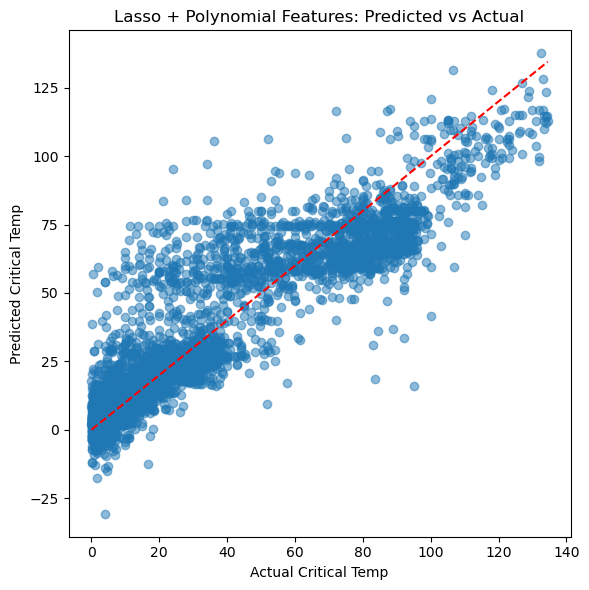

In [31]:
# ----------------------------------------------------
# POLYNOMIAL FEATURES + LASSO (MODEL 2)
# ----------------------------------------------------
# Why? Higher-order interactions may improve nonlinear relationships.

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

lasso_poly = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso_poly.fit(X_train_poly, y_train)

y_pred_poly = lasso_poly.predict(X_test_poly)

print("\n===== LASSO + POLYNOMIAL FEATURES =====")
print(f"R²: {r2_score(y_test, y_pred_poly):.3f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_poly):.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Critical Temp")
plt.ylabel("Predicted Critical Temp")
plt.title("Lasso + Polynomial Features: Predicted vs Actual")
plt.tight_layout()
plt.show()

In [8]:
X_train_poly.shape

NameError: name 'X_train_poly' is not defined